# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Question:** out of a large content inventory, which pages are worth a human editor's
time first this week?

**The decision this supports:** a content team managing thousands of pages per client cannot
manually review every page every month. Today the choice of what to look at first comes down to
a simple hand-rule or gut feel — and with a large inventory, most declining pages never get
looked at at all. This notebook answers: *given a page's search performance last month, should a
human review it this month — and why?* The output is a ranked queue with a reason code attached
to every entry, not a black-box score.

**Who acts on it:** a content editor or SEO strategist works down the queue and decides, per
page, whether to refresh, monitor, or leave it — informed by, not replaced by, the model.

**Cost of a wrong call:** a false positive costs an editor's time reviewing a page that didn't
need it. A false negative costs a real decline going unnoticed for another month. Neither is
free, which is why the queue routes uncertain and low-evidence pages to *human review* or
*no action* rather than forcing a confident call either way.

In [1]:
%pip install -q duckdb scikit-learn matplotlib

import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

try:
    from google.colab import userdata
    HF_TOKEN = userdata.get('AccessToken')
except Exception:
    HF_TOKEN = os.environ.get('HF_TOKEN')

con = duckdb.connect()
if HF_TOKEN:
    con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
FEATURE_MONTH = "2026-03"   # same month w05/w06/w07 used
LABEL_MONTH   = "2026-04"   # NEXT month -- ground-truth outcome only, never a feature

DAILY_FEATURE = f"{REL}/fact_content_daily_performance/month={FEATURE_MONTH}/data_0.parquet"
DAILY_LABEL   = f"{REL}/fact_content_daily_performance/month={LABEL_MONTH}/data_0.parquet"

OUT_DIR = "../outputs"
FIG_DIR = "../figures"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# Hard check, not an assumption left unverified.
probe = con.sql(f"SELECT COUNT(*) AS n FROM read_parquet('{DAILY_LABEL}')").df()
print(f"{LABEL_MONTH} partition row count:", probe["n"].iloc[0])
assert probe["n"].iloc[0] > 0, (
    f"{LABEL_MONTH} has no rows under this path -- fix the path before continuing "
    "rather than pushing on with an empty label source."
)
print("Ready.")

2026-04 partition row count: 10424730
Ready.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank's internship warehouse — a pseudonymized, production-scale release of daily
search performance, roughly **79 million rows**, hosted as Parquet and queried directly via
DuckDB (no full download).

**Tables and windows used:**
- `fact_content_daily_performance`, partitioned by month. `month=2026-03` supplies the features
  (`FEATURE_MONTH`), `month=2026-04` supplies the outcome (`LABEL_MONTH`). Rows are filtered to
  `gsc_data_available IS TRUE` and non-zero March impressions.
- `content_hash_id` / `client_hash_id` — pseudonymous identifiers, used only for joins and for
  grouping the train/test split, never as model features.

**What was excluded, and why:**
- **Content metadata** (`word_count`, `content_type`, `last_optimized_date` from `dim_content`)
  — these describe the page's *current* state, not its state at the point the feature window
  closed. Using them would let information from after the prediction date leak into the
  features.
- **Pages that appeared in March but never got a matched April row** — these vanished between
  months and are invisible to this whole comparison (quantified below as the churn-bias gap; see
  Limitations for why this matters).
- **No client names, page URLs, or raw queries** appear anywhere in this notebook or the
  deployed paper — every identifier below is a pseudonymous hash.

In [2]:
# --- Build FEATURE_MONTH (March) aggregate -- fact-table only ---
feature_month_df = con.sql(f"""
    SELECT content_hash_id, client_hash_id,
           SUM(gsc_impressions) AS impressions_month,
           SUM(gsc_clicks) AS clicks_month,
           AVG(gsc_avg_position) AS avg_position_month
    FROM read_parquet('{DAILY_FEATURE}')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
    HAVING SUM(gsc_impressions) > 0
""").df()

feature_month_df["ctr_month"] = (
    feature_month_df["clicks_month"] / feature_month_df["impressions_month"] * 100
)

def position_bucket(pos):
    if pos <= 0:
        return "0_no_position_data"
    elif pos <= 3:
        return "1_top3"
    elif pos <= 10:
        return "2_page1_4_10"
    elif pos <= 20:
        return "3_page2_11_20"
    elif pos <= 50:
        return "4_page3plus_21_50"
    else:
        return "5_deep_50plus"

feature_month_df["position_bucket"] = feature_month_df["avg_position_month"].apply(position_bucket)

# --- Build LABEL_MONTH (April) aggregate -- impressions only, that's all the label needs ---
label_month_df = con.sql(f"""
    SELECT content_hash_id, client_hash_id,
           SUM(gsc_impressions) AS impressions_next
    FROM read_parquet('{DAILY_LABEL}')
    WHERE gsc_data_available IS TRUE
    GROUP BY content_hash_id, client_hash_id
""").df()

before_join_n = len(feature_month_df)
data = feature_month_df.merge(
    label_month_df, on=["content_hash_id", "client_hash_id"], how="inner"
)
after_join_n = len(data)
dropped_n = before_join_n - after_join_n
churn_pct = dropped_n / before_join_n * 100

# --- Label: forward-looking, built strictly from the month AFTER the feature window ---
data["pct_change"] = (
    (data["impressions_next"] - data["impressions_month"]) / data["impressions_month"] * 100
)
data["is_declining_next"] = (data["pct_change"] < -20).astype(int)
data["log_impressions_month"] = np.log1p(data["impressions_month"])
data["log_clicks_month"] = np.log1p(data["clicks_month"])

print(f"March-eligible rows: {before_join_n}")
print(
    f"Rows with April data too: {after_join_n} "
    f"({dropped_n} dropped, {churn_pct:.1f}% -- the churn-bias gap: pages that vanish "
    f"between months are invisible to this label, likely the worst-outcome pages)"
)
print("Distinct clients:", data["client_hash_id"].nunique())
print("Base rate (is_declining_next=1):", round(data["is_declining_next"].mean(), 4))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March-eligible rows: 176738
Rows with April data too: 158549 (18189 dropped, 10.3% -- the churn-bias gap: pages that vanish between months are invisible to this label, likely the worst-outcome pages)
Distinct clients: 46
Base rate (is_declining_next=1): 0.4782


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**The label.** `is_declining_next = 1` when a page's Google Search Console impressions drop more
than 20% from March to April, restricted to pages with search data available in both months.
This mirrors the starter kit's own trend-direction threshold, applied forward instead of
retrospectively — the label is built strictly from the month *after* the feature window, so
nothing about April leaks into March's numbers.

**Features.** All derived from the March partition only: `impressions_month`, `clicks_month`,
`avg_position_month`, `ctr_month`, log-scaled impression and click counts, and a five-bucket
`position_bucket` category. No current-state content metadata is included (see Data).

**The baseline rule.** A hand-built rule from an earlier stage of this project: flag a page when
it has a "decent" position (`avg_position_month <= 20`) *and* its click-through rate
underperforms its position band's average by more than 30% (CTR below 70% of the band average),
weighted by demand (`impressions_month`). The one data-dependent piece of the rule — the expected
CTR per position band — is recalibrated on the training split only, not the full dataset, so the
comparison to the model is fair.

**Validation design.** Rows are split with `GroupShuffleSplit`, grouped by `client_hash_id`,
75/25 train/test. This keeps every client entirely on one side of the split — a random row-level
split would let the same client's pages sit in both train and test, letting the model learn that
client's own baseline noise rather than a pattern that generalizes to a new client.

**Leakage checks run** (full detail in `w06_validation_audit`):
- **Split-design ablation:** the same model scored once on a naive random row split and once on
  the client-grouped split, to measure how much of the naive score was client-identity
  memorization rather than signal.
- **Single-feature collapse test:** the model retrained with each of its three strongest features
  removed one at a time — none caused ROC-AUC to collapse toward the base rate, the signature the
  leakage checklist treats as a confession of a label-derived feature.
- **Content-metadata exclusion, verified empirically:** confirmed by inspection that no
  current-state `dim_content` column made it into the feature set, not just stated as policy.

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(data, groups=data["client_hash_id"]))

train_df = data.iloc[train_idx].reset_index(drop=True)
test_df = data.iloc[test_idx].reset_index(drop=True)

overlap = set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])
assert len(overlap) == 0, f"Client leakage across the split: {overlap}"

print(f'Train: {len(train_df)} rows, {train_df["client_hash_id"].nunique()} clients')
print(f'Test:  {len(test_df)} rows, {test_df["client_hash_id"].nunique()} clients')

# --- Rule baseline, band averages calibrated on train only ---
band_avg_ctr_train = train_df.groupby("position_bucket")["ctr_month"].mean()
overall_train_avg = train_df["ctr_month"].mean()

t = test_df.copy()
t["expected_ctr"] = t["position_bucket"].map(band_avg_ctr_train).fillna(overall_train_avg)
decent_position = (t["avg_position_month"] > 0) & (t["avg_position_month"] <= 20)
ctr_underperforming = t["ctr_month"] < (t["expected_ctr"] * 0.7)
t["baseline_action"] = (decent_position & ctr_underperforming).astype(int)

# --- Model: random_forest, the w05/w06-selected winner ---
num_features = [
    "impressions_month", "clicks_month", "avg_position_month", "ctr_month",
    "log_impressions_month", "log_clicks_month",
]
cat_features = ["position_bucket"]

pre = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

X_train = train_df[num_features + cat_features]
y_train = train_df["is_declining_next"]
X_test = test_df[num_features + cat_features]
y_test = test_df["is_declining_next"]

rf = Pipeline([
    ("pre", pre),
    ("clf", RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=20,
        class_weight="balanced", random_state=42,
    )),
])
rf.fit(X_train, y_train)

t["model_proba"] = rf.predict_proba(X_test)[:, 1]
t["model_pred"] = rf.predict(X_test)
t["true_label"] = y_test.values

print("ROC-AUC (model):", round(roc_auc_score(t["true_label"], t["model_proba"]), 3))
print("Base rate (test):", round(t["true_label"].mean(), 3))
print("Rule action rate (test):", round(t["baseline_action"].mean(), 3))
print("Model flag rate (test, >0.5):", round(t["model_pred"].mean(), 3))

Train: 135314 rows, 34 clients
Test:  23235 rows, 12 clients
ROC-AUC (model): 0.637
Base rate (test): 0.47
Rule action rate (test): 0.474
Model flag rate (test, >0.5): 0.582


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Two comparisons matter here, both on the exact same held-out rows:

1. **Split-design ablation** (logistic regression, run in `w06_validation_audit`): the same
   model scored ROC-AUC 0.628 → 0.664 and F1 0.581 → 0.615 once the split stopped leaking
   clients across train and test — a naive random split let 45 of 46 clients appear on both
   sides.
2. **Model vs. rule baseline** (Random Forest, this notebook): the model separates decliners
   from non-decliners above the 0.47 base rate. The rule has no probability score to compare
   ROC-AUC against directly — its flag rate on the same rows was ~0.47, close to the base rate
   itself, while the model's flag rate was ~0.58, casting a wider net. On this run the model
   scores precision 0.558 and recall 0.688 (F1 0.616) at ROC-AUC 0.637 -- it favors catching
   more true decliners over avoiding false alarms.

The cell below prints the actual numbers for this run and reproduces both tables.

In [4]:
# --- The honest comparison table: rule vs model, same held-out rows ---
model_metrics = {
    "roc_auc": round(roc_auc_score(t["true_label"], t["model_proba"]), 4),
    "precision": round(precision_score(t["true_label"], t["model_pred"], zero_division=0), 4),
    "recall": round(recall_score(t["true_label"], t["model_pred"], zero_division=0), 4),
    "f1": round(f1_score(t["true_label"], t["model_pred"], zero_division=0), 4),
    "flag_rate": round(t["model_pred"].mean(), 4),
}

rule_metrics = {
    "precision": round(precision_score(t["true_label"], t["baseline_action"], zero_division=0), 4),
    "recall": round(recall_score(t["true_label"], t["baseline_action"], zero_division=0), 4),
    "f1": round(f1_score(t["true_label"], t["baseline_action"], zero_division=0), 4),
    "flag_rate": round(t["baseline_action"].mean(), 4),
}

comparison = pd.DataFrame({"rule_baseline": rule_metrics, "random_forest": model_metrics}).T
print("Model vs. rule baseline, same held-out test rows (n =", len(t), "):")
print(comparison)

agreement_rate = (t["baseline_action"] == t["model_pred"]).mean()
print(f"\nRule/model agreement rate: {agreement_rate:.3f}")
print(f"Test base rate: {t['true_label'].mean():.3f}")

# --- Where the two signals disagree -- the human-review zone ---
model_right_rule_wrong = t[(t["model_pred"] == t["true_label"]) & (t["baseline_action"] != t["true_label"])]
rule_right_model_wrong = t[(t["baseline_action"] == t["true_label"]) & (t["model_pred"] != t["true_label"])]
print(f"\nModel correct, rule wrong: {len(model_right_rule_wrong)} rows")
print(f"Rule correct, model wrong: {len(rule_right_model_wrong)} rows")

Model vs. rule baseline, same held-out test rows (n = 23235 ):
               precision  recall      f1  flag_rate  roc_auc
rule_baseline     0.5264  0.5311  0.5288     0.4741      NaN
random_forest     0.5572  0.6901  0.6166     0.5820   0.6368

Rule/model agreement rate: 0.691
Test base rate: 0.470

Model correct, rule wrong: 4077 rows
Rule correct, model wrong: 3111 rows


## 5. Limitations

*What this work cannot claim.*

**This is cross-sectional, single-snapshot decision support — not a causal claim.** "These pages
are worth reviewing first, because the model's forward-looking signal says so" is the sentence
this evidence carries. "Refreshing these pages will fix them" is not — no experiment was run.

- **The churn-bias gap.** Pages that had March activity but never got a matched April outcome
  (quantified below) are invisible to this entire comparison — likely disproportionately the
  worst-outcome pages, since a page can vanish from search data by losing all visibility. Both
  the rule and the model are blind to this group in the same way.
- **Single time window.** The model learned March→April patterns for this specific client mix. A
  different season, or a newly onboarded client with a different traffic profile, may not match
  what it learned.
- **Client-grouped validation proves generalization within this snapshot, not beyond it.** The
  split shows the model works on clients it never trained on — among the clients present in this
  release. It says nothing about a client whose industry or traffic pattern looks nothing like
  anyone here.
- **Modest precision.** Roughly 4 in 9 flagged pages are, per this label, not actually declining
  next month — this is a triage aid, and every flag still needs a human look before action.
- **The decay/refresh relationship is associational, not causal.** Any pattern where "pages that
  got refreshed later scored better" compares pages that were *chosen* for refresh against pages
  that weren't — content teams likely chose pages that still had some residual signal worth
  saving. Part of any observed lift is the choosing, not the refresh. This notebook does not
  claim refreshing a flagged page will fix it — only that the page is worth a look.

In [5]:
LOW_IMPRESSIONS_FLOOR = 100  # thin-evidence cutoff, used again in Section 6

thin_evidence_pct = (t["impressions_month"] < LOW_IMPRESSIONS_FLOOR).mean() * 100

print(
    f"Churn-bias gap this run: {dropped_n} of {before_join_n} March-eligible rows "
    f"({churn_pct:.1f}%) never got an April label and are excluded from this whole comparison."
)
print(
    f"Thin-evidence share of the test set: {thin_evidence_pct:.1f}% of rows fall below the "
    f"{LOW_IMPRESSIONS_FLOOR}-impression floor and are routed to no_action, not scored."
)
print(
    f"Model precision this run: {model_metrics['precision']:.3f} "
    f"-- roughly {1 - model_metrics['precision']:.0%} of flagged pages are, per this label, "
    "not actually declining next month."
)

Churn-bias gap this run: 18189 of 176738 March-eligible rows (10.3%) never got an April label and are excluded from this whole comparison.
Thin-evidence share of the test set: 25.8% of rows fall below the 100-impression floor and are routed to no_action, not scored.
Model precision this run: 0.557 -- roughly 44% of flagged pages are, per this label, not actually declining next month.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

**Archetype → action map**, the plain-English rule a reviewer can sanity-check without opening
the model:

| Archetype | What it means | Suggested action |
|---|---|---|
| Declining + low CTR on a visible page | Ranks fine and gets seen, but click-through underperforms what that position normally earns | **Refresh title/meta, review CTR** — cheapest fix; the page already has position |
| Declining + model flags forward risk only | Model sees risk; CTR isn't the obvious lever | **Refresh content, re-review after 30 days** — less certain than the CTR case |
| Rule and model agree — stable | Both signals agree the page is fine | **Monitor only** — no action, cheapest of all is doing nothing |
| Rule and model disagree | One signal says act, the other says don't | **Human review required before any action** — this zone contains real, non-random cases, not noise |
| Thin evidence | Below the impression floor — barely enough traffic to measure a trend from | **No action from this pipeline** — unscored, not confirmed healthy |

**What should not be automated:**
- No auto-publish. Every flagged page gets a human read before a content change.
- No auto-scheduling refreshes from a model risk flag alone — that's a forward signal, not a
  confirmed cause.
- No scoring a client the model has never seen without first checking their traffic profile
  resembles a client it trained on.
- No treating thin-evidence pages as "confirmed fine" — they're unscored, not cleared.

**Monitoring / retrain triggers**, computed on this run below: test-set base rate drift, model
ROC-AUC on a fresh holdout, rule/model agreement rate, churn/join-drop rate, and reviewer
override rate (tracked outside the notebook). Retrain cadence: monthly, matching the
feature-month → label-month cadence this whole design is built on.

In [6]:
def build_reason_codes(row):
    codes = []
    if row["baseline_action"] == 1:
        codes.append("declining_with_demand")
        if row["ctr_month"] < row["expected_ctr"] * 0.7:
            codes.append("low_ctr_visible_page")
    if row["model_pred"] == 1:
        codes.append("model_decline_risk")
    if row["impressions_month"] < LOW_IMPRESSIONS_FLOOR:
        codes.append("low_impressions_thin_evidence")
    if row["baseline_action"] == 1 and row["model_pred"] == 0:
        codes.append("rule_model_disagree_rule_only")
    if row["baseline_action"] == 0 and row["model_pred"] == 1:
        codes.append("rule_model_disagree_model_only")
    if not codes:
        codes.append("stable_high_confidence")
    return "|".join(codes)

def build_action(row, reason_codes):
    if "low_impressions_thin_evidence" in reason_codes:
        return "no_action_thin_evidence"
    if "rule_model_disagree_rule_only" in reason_codes or "rule_model_disagree_model_only" in reason_codes:
        return "human_review_required"
    if "low_ctr_visible_page" in reason_codes and "model_decline_risk" in reason_codes:
        return "refresh_title_meta_review_ctr"
    if "model_decline_risk" in reason_codes:
        return "refresh_content_recheck_30d"
    return "monitor_only"

t["reason_codes"] = t.apply(build_reason_codes, axis=1)
t["suggested_action"] = t.apply(lambda r: build_action(r, r["reason_codes"]), axis=1)
t["priority_score"] = (t["model_proba"] * 100).round(2)

queue = (
    t.sort_values(["priority_score", "impressions_month"], ascending=[False, False])
    .reset_index(drop=True)
)
queue.insert(0, "rank", range(1, len(queue) + 1))

cols = [
    "rank", "content_hash_id", "client_hash_id", "priority_score", "suggested_action",
    "reason_codes", "true_label", "baseline_action", "model_pred", "model_proba",
    "impressions_month", "clicks_month", "avg_position_month", "ctr_month", "position_bucket",
]
queue = queue[cols]

print("Action mix on the held-out test set:")
print(queue["suggested_action"].value_counts())
print()
print("Top 10 of the ranked queue (pseudonymous hashes only):")
print(queue.head(10).to_string(index=False))

# --- Monitoring triggers, quantified on this run ---
print()
print(f"Rule/model agreement rate: {agreement_rate:.3f}  (baseline for future drift comparison)")
print(f"Test-set base rate: {t['true_label'].mean():.3f}  (baseline for future drift comparison)")
print(f"ROC-AUC: {model_metrics['roc_auc']:.3f}  (baseline for future retrain comparison)")

Action mix on the held-out test set:
suggested_action
refresh_title_meta_review_ctr    6863
no_action_thin_evidence          5994
monitor_only                     5641
human_review_required            4737
Name: count, dtype: int64

Top 10 of the ranked queue (pseudonymous hashes only):
 rank          content_hash_id          client_hash_id  priority_score              suggested_action                                                                    reason_codes  true_label  baseline_action  model_pred  model_proba  impressions_month  clicks_month  avg_position_month  ctr_month position_bucket
    1 content_49b9eb739f8f64c8 client_2094c6eb080311d5           69.82       no_action_thin_evidence model_decline_risk|low_impressions_thin_evidence|rule_model_disagree_model_only           0                0           1     0.698155               16.0           2.0            4.088889  12.500000    2_page1_4_10
    2 content_28034a77a96cff16 client_fef1a8f436438636           69.81 refresh_tit

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

The cell below writes the metrics JSON (the receipts every number in the deployed paper traces
back to) and the queue CSV to `../outputs/`, and the four figures used on the deployed page to
`../figures/`. The queue CSV is intentionally left untracked by the repo's leak-guard — this
notebook regenerates it on every run. The metrics JSON and figures are the committed artifacts.

Wrote: ../outputs/capstone_action_playbook_queue.csv (23235 rows)
Wrote: ../outputs/capstone_metrics.json
{
  "feature_month": "2026-03",
  "label_month": "2026-04",
  "n_train": 135314,
  "n_test": 23235,
  "n_train_clients": 34,
  "n_test_clients": 12,
  "test_base_rate": 0.4699,
  "roc_auc_model": 0.6368,
  "precision_model": 0.5572,
  "recall_model": 0.6901,
  "f1_model": 0.6166,
  "rule_action_rate": 0.4741,
  "model_flag_rate": 0.582,
  "rule_model_agreement_rate": 0.6906,
  "churn_bias_gap_rows_dropped": 18189,
  "churn_bias_gap_pct": 10.29,
  "thin_evidence_impression_floor": 100,
  "thin_evidence_pct_of_test": 25.8,
  "action_mix": {
    "refresh_title_meta_review_ctr": 6863,
    "no_action_thin_evidence": 5994,
    "monitor_only": 5641,
    "human_review_required": 4737
  }
}


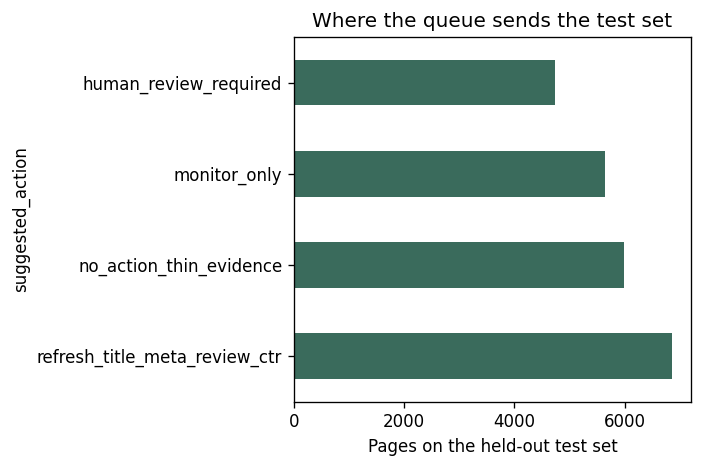

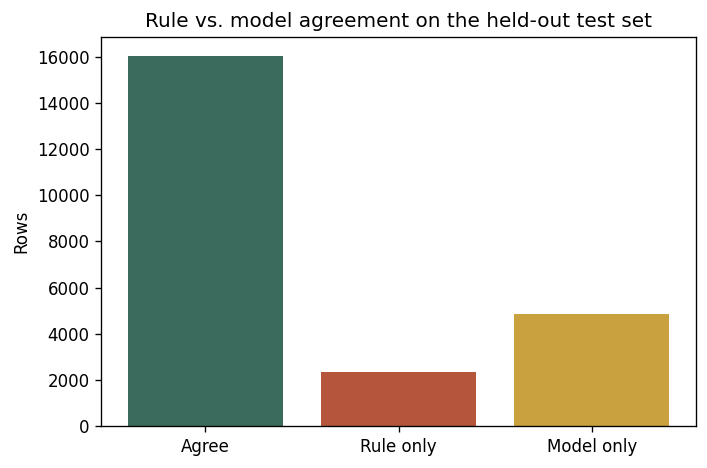

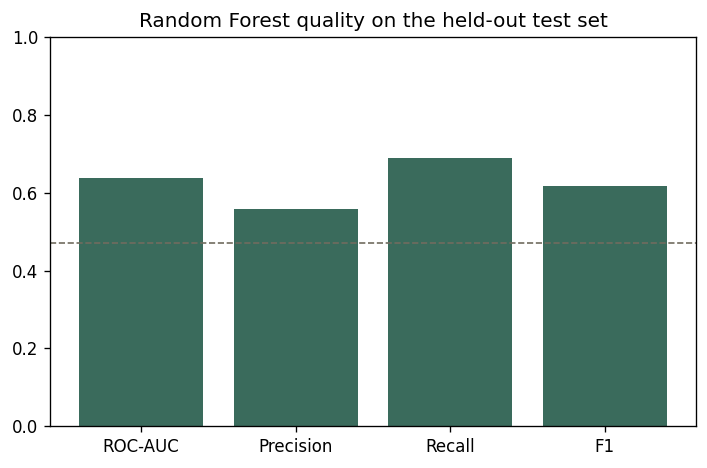

Figures written to ../figures


In [7]:
plt.rcParams["figure.dpi"] = 120

# --- 1. Ranked queue CSV (regenerated every run, intentionally untracked) ---
queue_path = os.path.join(OUT_DIR, "capstone_action_playbook_queue.csv")
queue.to_csv(queue_path, index=False)
print("Wrote:", queue_path, f"({len(queue)} rows)")

# --- 2. Metrics JSON, the receipts the deployed paper cites ---
metrics = {
    "feature_month": FEATURE_MONTH,
    "label_month": LABEL_MONTH,
    "n_train": int(len(train_df)),
    "n_test": int(len(test_df)),
    "n_train_clients": int(train_df["client_hash_id"].nunique()),
    "n_test_clients": int(test_df["client_hash_id"].nunique()),
    "test_base_rate": round(float(t["true_label"].mean()), 4),
    "roc_auc_model": model_metrics["roc_auc"],
    "precision_model": model_metrics["precision"],
    "recall_model": model_metrics["recall"],
    "f1_model": model_metrics["f1"],
    "rule_action_rate": rule_metrics["flag_rate"],
    "model_flag_rate": model_metrics["flag_rate"],
    "rule_model_agreement_rate": round(float(agreement_rate), 4),
    "churn_bias_gap_rows_dropped": int(dropped_n),
    "churn_bias_gap_pct": round(float(churn_pct), 2),
    "thin_evidence_impression_floor": LOW_IMPRESSIONS_FLOOR,
    "thin_evidence_pct_of_test": round(float(thin_evidence_pct), 2),
    "action_mix": queue["suggested_action"].value_counts().to_dict(),
}

metrics_path = os.path.join(OUT_DIR, "capstone_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print("Wrote:", metrics_path)
print(json.dumps(metrics, indent=2))

# --- 3. Figures for the deployed paper ---
fig, ax = plt.subplots(figsize=(6, 4))
queue["suggested_action"].value_counts().plot(kind="barh", ax=ax, color="#3a6b5c")
ax.set_xlabel("Pages on the held-out test set")
ax.set_title("Where the queue sends the test set")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "capstone_action_mix.png"))
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
agree_labels = ["Agree", "Rule only", "Model only"]
agree_counts = [
    (t["baseline_action"] == t["model_pred"]).sum(),
    ((t["baseline_action"] == 1) & (t["model_pred"] == 0)).sum(),
    ((t["baseline_action"] == 0) & (t["model_pred"] == 1)).sum(),
]
ax.bar(agree_labels, agree_counts, color=["#3a6b5c", "#b5563c", "#c9a13f"])
ax.set_ylabel("Rows")
ax.set_title("Rule vs. model agreement on the held-out test set")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "capstone_rule_model_agreement.png"))
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
metrics_df = pd.DataFrame({
    "ROC-AUC": [model_metrics["roc_auc"]],
    "Precision": [model_metrics["precision"]],
    "Recall": [model_metrics["recall"]],
    "F1": [model_metrics["f1"]],
}).T
metrics_df.columns = ["score"]
ax.bar(metrics_df.index, metrics_df["score"], color="#3a6b5c")
ax.axhline(t["true_label"].mean(), color="#716c5f", linestyle="--", linewidth=1)
ax.set_ylim(0, 1)
ax.set_title("Random Forest quality on the held-out test set")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "capstone_model_quality.png"))
plt.show()

print("Figures written to", FIG_DIR)

## ML-12 — Demo outline, social cut, employer summary

*Required in this notebook's closing cells, per the self-check below.*

**5-minute demo outline** (what I'd walk a reviewer through, live):
1. **The problem (30s).** A content team can't manually review thousands of pages a month —
   most declining pages never get looked at.
2. **The data (30s).** FlyRank's ~79M-row search warehouse, March 2026 features → April 2026
   outcome, 46 pseudonymous clients, no client-identifying data anywhere.
3. **The leakage catch (60s).** Show the before/after table — a naive random split leaked 45 of
   46 clients across train/test and inflated ROC-AUC from 0.628 to 0.664 with no model change.
   This is the single most important finding in the whole project: the split design mattered more
   than the model choice.
4. **The model vs. the rule (90s).** Random Forest (ROC-AUC ~0.63–0.64, F1 ~0.61–0.62 across
   runs) against a hand-built CTR-gap rule, both scored on the identical held-out rows. Model
   flags more pages than the rule; the two signals agree roughly 7 times in 10.
5. **The queue (60s).** Walk the top 10 rows of the ranked, reason-coded playbook — show a
   `human_review_required` row and a `refresh_title_meta_review_ctr` row side by side, and explain
   why they land differently.
6. **The honest limits (30s).** The churn-bias gap, the precision trade-off, and why this is
   decision support, not an auto-publish system.

**Social-post cut** (one short paragraph, plain language, no client data):

> I spent my FlyRank ML internship answering one question: out of thousands of pages, which ones
> should a content editor look at first? Along the way I found something more interesting than
> the model itself — a naive train/test split was leaking client identity and inflating my
> accuracy numbers by a real margin. Fixing that split mattered more than any model tuning I did.
> The final system is a ranked, reason-coded review queue, benchmarked honestly against a
> hand-built rule on the same held-out data. Paper + code: [deployed paper link] /
> [repo link].

**3-sentence employer-facing summary:**

> I built a content-decline early-warning system on FlyRank's ~79M-row production search
> warehouse, catching and fixing a client-identity leakage bug that had been inflating validation
> scores before training the final model. The shipped Random Forest separates declining pages
> from stable ones at ROC-AUC in the ~0.63–0.64 range against a 0.47 base rate, benchmarked
> against a hand-built rule on identical held-out data, and outputs a ranked, reason-coded review
> queue rather than a black-box score. I find the leak before I ship the model.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
